In [174]:
from dataclasses import asdict
from pathlib import Path
import sys

import pandas as pd


def _find_examples_python(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "examples" / "python" / "tensor_backend_scaling_rk4ip.py").is_file():
            return candidate / "examples" / "python"
        if (candidate / "tensor_backend_scaling_rk4ip.py").is_file() and candidate.name == "python":
            return candidate
    raise RuntimeError("Could not locate examples/python from the current notebook path.")


EXAMPLES_PYTHON = _find_examples_python()
REPO_ROOT = EXAMPLES_PYTHON.parents[1]
if str(EXAMPLES_PYTHON) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_PYTHON))

from backend.storage import ExampleRunDB
from tensor_backend_scaling_rk4ip import (
    _MIXED_MODE_RUNTIME_PLOT_SPEC,
    _MIXED_RUNTIME_PLOT_SPEC,
    _NLOLIB_RUNTIME_PLOT_SPEC,
    _load_benchmark_rows,
    _read_benchmark_rows_csv,
    _runtime_plot_rows,
    _series_rows,
    _series_xy,
    _series_yerr,
)


RUN_SOURCES = [
    {
        "script": "tensor_backend_scaling_rk4ip.py",
        "example_name": "tensor_backend_scaling",
        "db_path": REPO_ROOT / "output" / "db" / "tensor_backend_scaling.sqlite3",
        "fallback_csv": EXAMPLES_PYTHON / "output" / "tensor_backend_scaling" / "tensor_backend_scaling_results.csv",
        "plot_specs": {
            "runtime_by_state_points": _MIXED_RUNTIME_PLOT_SPEC,
            "runtime_by_mode_count": _MIXED_MODE_RUNTIME_PLOT_SPEC,
            "runtime_nlolib_only": _NLOLIB_RUNTIME_PLOT_SPEC,
        },
    },
    {
        "script": "tensor_backend_scaling_nlolib_rk4ip.py",
        "example_name": "tensor_backend_scaling_nlolib",
        "db_path": REPO_ROOT / "output" / "db" / "tensor_backend_scaling_nlolib.sqlite3",
        "fallback_csv": EXAMPLES_PYTHON / "output" / "tensor_backend_scaling_nlolib" / "tensor_backend_scaling_nlolib_results.csv",
        "plot_specs": {
            "runtime_nlolib_only": _NLOLIB_RUNTIME_PLOT_SPEC,
        },
    },
]


def load_latest_rows(source: dict) -> tuple[str, list]:
    db = ExampleRunDB(source["db_path"])
    try:
        run_group = db.resolve_replot_group(source["example_name"], None)
        rows = _load_benchmark_rows(db, example_name=source["example_name"], run_group=run_group)
        return run_group, rows
    except RuntimeError:
        rows = _read_benchmark_rows_csv(source["fallback_csv"])
        if not rows:
            raise
        return "csv_fallback", rows


benchmark_frames = []
plot_frames = []
for source in RUN_SOURCES:
    run_group, rows = load_latest_rows(source)
    benchmark_df_part = pd.DataFrame(asdict(row) for row in rows)
    benchmark_df_part.insert(0, "run_group", run_group)
    benchmark_df_part.insert(0, "source_script", source["script"])
    benchmark_frames.append(benchmark_df_part)

    for plot_name, plot_spec in source["plot_specs"].items():
        for series in plot_spec.series:
            series_rows = _series_rows(_runtime_plot_rows(rows), series)
            if not series_rows:
                continue
            x_values, y_values = _series_xy(series_rows, x_axis=plot_spec.x_axis)
            y_error = _series_yerr(series_rows)
            part = pd.DataFrame(asdict(row) for row in series_rows)
            part.insert(0, "source_script", source["script"])
            part.insert(1, "run_group", run_group)
            part.insert(2, "plot_name", plot_name)
            part.insert(3, "series_label", series.label)
            part.insert(4, "x_axis", plot_spec.x_axis)
            part.insert(5, "x", x_values)
            part.insert(6, "x_plotted", x_values / float(plot_spec.x_scale))
            part.insert(7, "y", y_values)
            part.insert(8, "yerr", y_error)
            plot_frames.append(part)

benchmark_df = pd.concat(benchmark_frames, ignore_index=True) if benchmark_frames else pd.DataFrame()
plot_df = pd.concat(plot_frames, ignore_index=True) if plot_frames else pd.DataFrame()

# Main fit-friendly DataFrame: one row per plotted marker per plot/series.
plot_df


,source_script,run_group,plot_name,series_label,x_axis,x,x_plotted,y,yerr,solver,...,nt,nx,ny,mode_count,total_points,runtime_seconds,runtime_seconds_std,throughput_points_per_second,status,message
0,tensor_backend_scaling_rk4ip.py,csv_fallback,runtime_by_state_points,nlolib GPU,state_points,9216.0,9.216,0.318216,0.017635,nlolib,...,1024,3,3,5,9216,0.318216,0.017635,28961.432837,ok,
1,tensor_backend_scaling_rk4ip.py,csv_fallback,runtime_by_state_points,nlolib GPU,state_points,16384.0,16.384,0.250247,0.007034,nlolib,...,1024,4,4,9,16384,0.250247,0.007034,65471.405910,ok,
2,tensor_backend_scaling_rk4ip.py,csv_fallback,runtime_by_state_points,nlolib GPU,state_points,25600.0,25.600,0.341092,0.006609,nlolib,...,1024,5,5,14,25600,0.341092,0.006609,75053.042859,ok,
3,tensor_backend_scaling_rk4ip.py,csv_fallback,runtime_by_state_points,nlolib GPU,state_points,36864.0,36.864,0.328940,0.041192,nlolib,...,1024,6,6,18,36864,0.328940,0.041192,112069.087382,ok,
4,tensor_backend_scaling_rk4ip.py,csv_fallback,runtime_by_state_points,nlolib GPU,state_points,50176.0,50.176,0.317891,0.016602,nlolib,...,1024,7,7,23,50176,0.317891,0.016602,157840.377720,ok,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,tensor_backend_scaling_nlolib_rk4ip.py,csv_fallback,runtime_nlolib_only,nlolib GPU,state_points,1882384.0,1882.384,2.391231,0.026124,nlolib,...,196,98,98,9604,1882384,2.391231,0.026124,787202.826996,ok,
79,tensor_backend_scaling_nlolib_rk4ip.py,csv_fallback,runtime_nlolib_only,nlolib GPU,state_points,3121792.0,3121.792,4.362906,0.176519,nlolib,...,232,116,116,13456,3121792,4.362906,0.176519,715530.469573,ok,
80,tensor_backend_scaling_nlolib_rk4ip.py,csv_fallback,runtime_nlolib_only,nlolib GPU,state_points,5142706.0,5142.706,8.526827,0.112727,nlolib,...,274,137,137,18769,5142706,8.526827,0.112727,603120.743654,ok,
81,tensor_backend_scaling_nlolib_rk4ip.py,csv_fallback,runtime_nlolib_only,nlolib GPU,state_points,8503056.0,8503.056,10.418533,0.334527,nlolib,...,324,162,162,26244,8503056,10.418533,0.334527,816147.126352,ok,


In [175]:
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "cm"

from scipy.optimize import curve_fit
import numpy as np
%matplotlib inline

In [176]:
mmtools_mode_df = plot_df.where(
    (plot_df["source_script"] == "tensor_backend_scaling_rk4ip.py") &
    (plot_df["series_label"] == "MMTools GPU") &
    (plot_df["x_axis"] == "mode_count")
)[["mode_count", "runtime_seconds", "runtime_seconds_std"]]
mmtools_mode_df.dropna(inplace=True)
mmtools_mode_df

,mode_count,runtime_seconds,runtime_seconds_std
30,4.0,9.821283,0.547390
31,5.0,8.659894,0.421584
32,7.0,8.877990,0.230655
33,9.0,8.874779,0.393874
34,11.0,9.347830,0.523419
35,14.0,10.794313,0.226783
36,18.0,13.359893,0.769913
37,23.0,17.257049,0.347060
38,30.0,26.704831,0.484240
39,39.0,37.789968,0.673562


In [177]:
nlolib_mode_df = plot_df.where(
    (plot_df["source_script"] == "tensor_backend_scaling_rk4ip.py") &
    (plot_df["series_label"] == "nlolib GPU") &
    (plot_df["x_axis"] == "mode_count")
)[["mode_count", "runtime_seconds", "runtime_seconds_std"]]
nlolib_mode_df.dropna(inplace=True)
nlolib_mode_df

,mode_count,runtime_seconds,runtime_seconds_std
21,5.0,0.318216,0.017635
22,9.0,0.250247,0.007034
23,14.0,0.341092,0.006609
24,18.0,0.328940,0.041192
25,23.0,0.317891,0.016602
26,30.0,0.366858,0.008629
27,39.0,0.396408,0.013348
28,50.0,0.546849,0.193973
29,64.0,0.422873,0.006527


In [178]:
def n_exp_n(n, a, b, c):
    return a * n**b + c

def n_log_n(n, a, b, c):
    return a * n * np.log(n) + b * n + c

popt_mmtools, _ = curve_fit(n_exp_n, mmtools_mode_df["mode_count"], mmtools_mode_df["runtime_seconds"], sigma=mmtools_mode_df["runtime_seconds_std"])
mmtools_mode_line = np.linspace(mmtools_mode_df["mode_count"].min(), mmtools_mode_df["mode_count"].max(), 100)
mmtools_mode_fit = n_exp_n(mmtools_mode_line, *popt_mmtools)

popt_nlolib, _ = curve_fit(n_log_n, nlolib_mode_df["mode_count"], nlolib_mode_df["runtime_seconds"], sigma=nlolib_mode_df["runtime_seconds_std"])
nlolib_mode_line = np.linspace(nlolib_mode_df["mode_count"].min(), nlolib_mode_df["mode_count"].max(), 100)
nlolib_mode_fit = n_log_n(nlolib_mode_line, *popt_nlolib)

C:\Users\Wenzel\AppData\Local\Temp\ipykernel_239564\2601464252.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


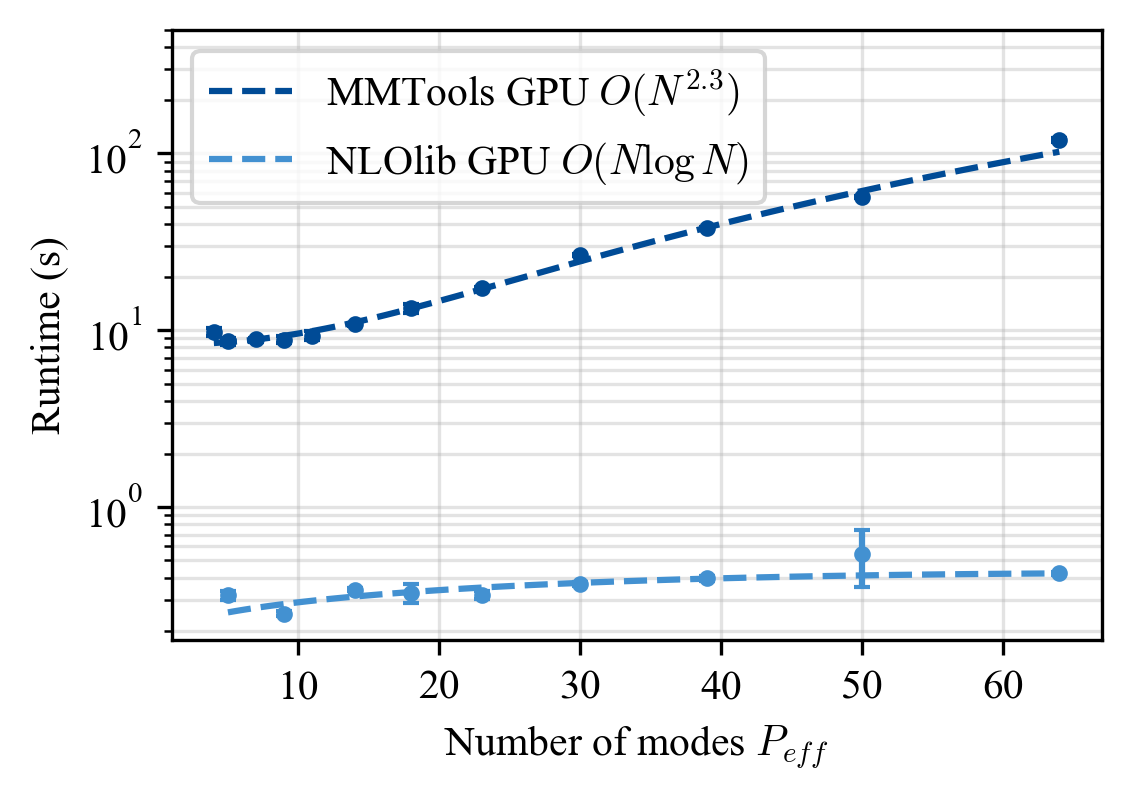

In [179]:
fig, ax = plt.subplots()

ax.errorbar(
    mmtools_mode_df["mode_count"],
    mmtools_mode_df["runtime_seconds"],
    yerr=mmtools_mode_df["runtime_seconds_std"],
    ls="none",
    markersize=3.0,
    marker="o",
    capsize=2.0,
    color="C1",
    
)
ax.plot(
    mmtools_mode_line,
    mmtools_mode_fit,
    label=r"MMTools GPU $O(N^{"+ f"{round(popt_mmtools[1], 1)}" + r"})$",
    ls="--",
    color="C1",
)
ax.errorbar(
    nlolib_mode_df["mode_count"],
    nlolib_mode_df["runtime_seconds"],
    yerr=nlolib_mode_df["runtime_seconds_std"],
    ls="none",
    markersize=3.0,
    marker="o",
    capsize=2.0,
    color="C2"
)
ax.plot(
    nlolib_mode_line,
    nlolib_mode_fit,
    label=r"NLOlib GPU $O(N\log N)$",
    ls="--",
    color="C2",
)
ax.grid(True, which="both", alpha=0.35)
ax.set_xlabel(r"Number of modes $P_{eff}$")
ax.set_ylabel("Runtime (s)")
ax.set_yscale("log")
ax.set_ylim(top=500)
ax.legend(loc="upper left")
fig.savefig(Path(r"C:\Users\Wenzel\Final Year Project\report\figs\tensor_backend_scaling_runtime.png"))
fig.show()

In [180]:
Path(r"C:\Users\Wenzel\Final Year Project\report\figs\tensor_backend_scaling_runtime.png")

WindowsPath('C:/Users/Wenzel/Final Year Project/report/figs/tensor_backend_scaling_runtime.png')

In [181]:
tensor_scaling_df = pd.read_csv(EXAMPLES_PYTHON / "output" / "tensor_backend_scaling_nlolib" / "tensor_backend_scaling_nlolib_results.csv")

In [182]:
nlolib_cpu_tensor_df = tensor_scaling_df.where(
    (tensor_scaling_df["backend"] == "CPU")
)[["total_points", "runtime_seconds", "runtime_seconds_std", "nx", "nt", "ny"]]
nlolib_cpu_tensor_df.dropna(inplace=True)
nlolib_cpu_tensor_df

,total_points,runtime_seconds,runtime_seconds_std,nx,nt,ny
0,8192.0,0.023761,0.000764,16.0,32.0,16.0
1,11664.0,0.048358,0.001072,18.0,36.0,18.0
2,21296.0,0.089100,0.001972,22.0,44.0,22.0
3,35152.0,0.172789,0.011858,26.0,52.0,26.0
4,59582.0,0.281720,0.009883,31.0,62.0,31.0
5,93312.0,0.382377,0.011615,36.0,72.0,36.0
6,159014.0,1.075038,0.027687,43.0,86.0,43.0
7,265302.0,1.304221,0.011333,51.0,102.0,51.0
8,432000.0,1.844668,0.109728,60.0,120.0,60.0
9,715822.0,6.178660,0.333349,71.0,142.0,71.0


In [183]:
nlolib_gpu_tensor_df = tensor_scaling_df.where(
    (tensor_scaling_df["backend"] == "GPU")
)[["total_points", "runtime_seconds", "runtime_seconds_std", "nx", "nt", "ny"]]
nlolib_gpu_tensor_df.dropna(inplace=True)
nlolib_gpu_tensor_df

,total_points,runtime_seconds,runtime_seconds_std,nx,nt,ny
16,8192.0,0.268828,0.012264,16.0,32.0,16.0
17,11664.0,0.307321,0.009390,18.0,36.0,18.0
18,21296.0,0.311419,0.011143,22.0,44.0,22.0
19,35152.0,0.384943,0.032338,26.0,52.0,26.0
20,59582.0,0.425922,0.018041,31.0,62.0,31.0
21,93312.0,0.374944,0.025700,36.0,72.0,36.0
22,159014.0,0.517806,0.015838,43.0,86.0,43.0
23,265302.0,0.807443,0.084101,51.0,102.0,51.0
24,432000.0,0.725448,0.034741,60.0,120.0,60.0
25,715822.0,1.261804,0.068174,71.0,142.0,71.0


In [184]:
def power_model(x, a, b, c):
    return a * x**b + c

def straight_line(x, m, c):
    return m * x + c

def exp_model_scaled(x, a, b, c):
    return x ** a * np.exp(b*np.log(x**2)) + c

# --- CPU fit ---
x_cpu = nlolib_cpu_tensor_df["total_points"].to_numpy(dtype=float)
y_cpu = nlolib_cpu_tensor_df["runtime_seconds"].to_numpy(dtype=float)

log_x_cpu = np.log(x_cpu)
log_y_cpu = np.log(y_cpu)

popt_cpu, pcov_cpu = curve_fit(
    straight_line,
    log_x_cpu,
    log_y_cpu,
)

log_cpu_line =  np.linspace(log_x_cpu.min(), log_x_cpu.max(), 200)
log_cpu_fit = straight_line(log_cpu_line, *popt_cpu)

cpu_line = np.exp(log_cpu_line)
cpu_fit = np.exp(log_cpu_fit)

# --- GPU soft-curved log-log fit ---
x_gpu_exp = nlolib_gpu_tensor_df["total_points"].to_numpy(dtype=float)[8:]
y_gpu_exp = nlolib_gpu_tensor_df["runtime_seconds"].to_numpy(dtype=float)[8:]

# keep only valid positive points
mask = np.isfinite(x_gpu_exp) & np.isfinite(y_gpu_exp) & (x_gpu_exp > 0) & (y_gpu_exp > 0)
x_gpu_exp = x_gpu_exp[mask]
y_gpu_exp = y_gpu_exp[mask]

# reference scale for numerical stability
x_ref = x_gpu_exp.max()

def soft_loglog_model(x, alpha, beta, gamma, c):
    u = np.log(x / x_ref)
    z = alpha + beta * u + gamma * u**2
    return np.exp(np.clip(z, -700, 700)) + c

popt_gpu, pcov_gpu = curve_fit(
    soft_loglog_model,
    x_gpu_exp,
    y_gpu_exp,
    bounds=([-np.inf, -2, -0.2, -np.inf],
            [ np.inf,  2,  0.2,  np.inf]),
    maxfev=20000
)

gpu_line = np.linspace(x_gpu_exp.min(), x_gpu_exp.max(), 200)
gpu_fit = soft_loglog_model(gpu_line, *popt_gpu)

# --- GPU power fit ---

log_x_gpu = np.log(nlolib_gpu_tensor_df["total_points"].to_numpy(dtype=float))[8:]
log_y_gpu = np.log(nlolib_gpu_tensor_df["runtime_seconds"].to_numpy(dtype=float))[8:]

popt_gpu_power, pcov_gpu_power = curve_fit(
    straight_line,
    log_x_gpu,
    log_y_gpu,
)

log_gpu_line =  np.linspace(log_x_gpu.min(), log_x_gpu.max(), 200)
log_gpu_fit = straight_line(log_gpu_line, *popt_gpu_power)

gpu_line_power = np.exp(log_gpu_line)
gpu_fit_power = np.exp(log_gpu_fit)

# --- GPU n log n fit ---

log_x_gpu_logn = nlolib_gpu_tensor_df["total_points"].to_numpy(dtype=float)[:9]
log_y_gpu_logn = nlolib_gpu_tensor_df["runtime_seconds"].to_numpy(dtype=float)[:9]

popt_gpu_logn, pcov_gpu_logn = curve_fit(
    n_log_n,
    log_x_gpu_logn,
    log_y_gpu_logn,
)

log_gpu_line_logn =  np.linspace(log_x_gpu_logn.min(), log_x_gpu_logn.max(), 200)
log_gpu_fit_logn = n_log_n(log_gpu_line_logn, *popt_gpu_logn)
gpu_line_logn = log_gpu_line_logn
gpu_fit_logn = log_gpu_fit_logn

In [185]:
popt_gpu_power

array([  1.05830712, -14.20618657])

C:\Users\Wenzel\AppData\Local\Temp\ipykernel_239564\3256594415.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


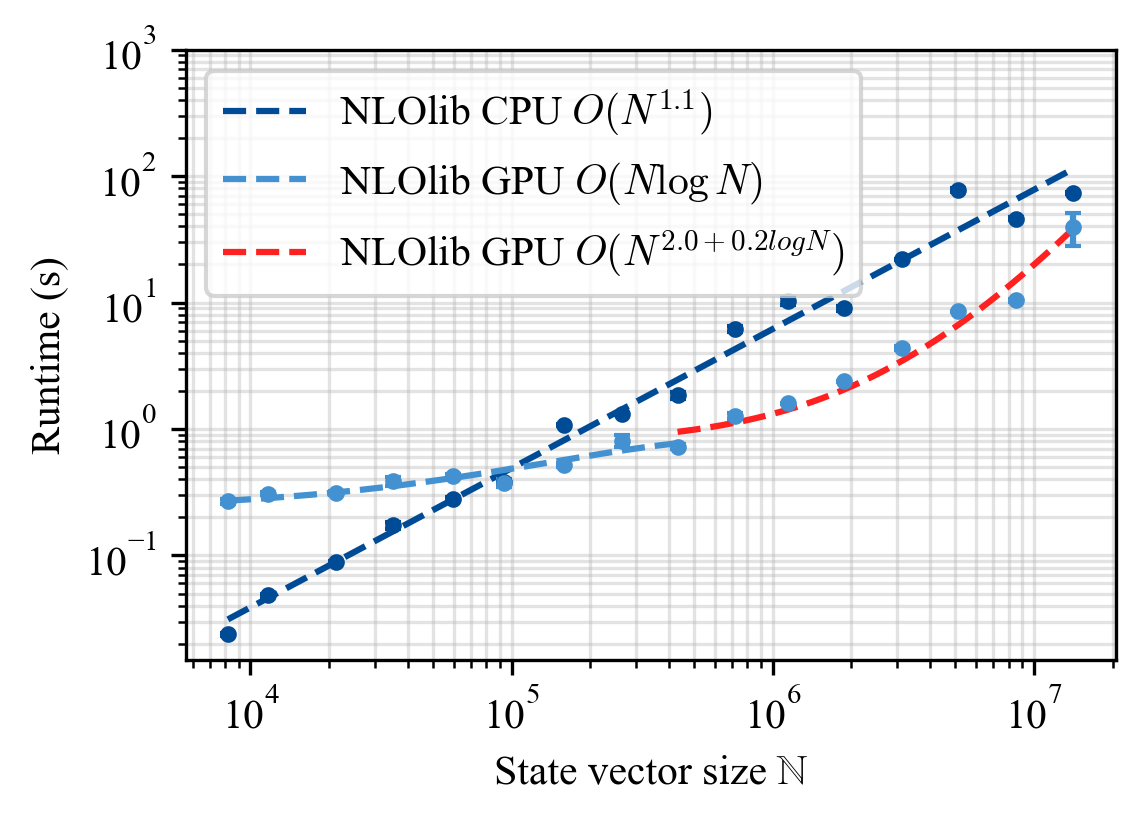

In [186]:
plt.rcParams["mathtext.fontset"] = "cm"

fig, ax = plt.subplots()

ax.errorbar(
    nlolib_cpu_tensor_df["total_points"],
    nlolib_cpu_tensor_df["runtime_seconds"],
    yerr=nlolib_cpu_tensor_df["runtime_seconds_std"],
    ls="none",
    markersize=3.0,
    marker="o",
    capsize=2.0,
    color="C1"
)
ax.plot(
    cpu_line,
    cpu_fit,
    label=r"NLOlib CPU $O(N^{"+ f"{round(popt_cpu[0], 1)}" + r"})$",
    ls="--",
    color="C1",
)


ax.errorbar(
    nlolib_gpu_tensor_df["total_points"],
    nlolib_gpu_tensor_df["runtime_seconds"],
    yerr=nlolib_gpu_tensor_df["runtime_seconds_std"],
    ls="none",
    markersize=3.0,
    marker="o",
    capsize=2.0,
    color="C2"
)
ax.plot(
    gpu_line_logn,
    gpu_fit_logn,
    label=r"NLOlib GPU $O(N \log N)$",
    ls="--",
    color="C2",
)
ax.plot(
    gpu_line,
    gpu_fit,
    label=r"NLOlib GPU $O(N^{"+ f"{round(popt_gpu[1], 1)}" + r" + " + f"{round(popt_gpu[2], 1)}" + " log N})$",
    ls="--",
    color="C3",
)

ax.loglog(True)
ax.set_xlabel(r"State vector size ℕ")
ax.set_ylabel("Runtime (s)")
ax.grid(True, which="both", alpha=0.35)
ax.legend(loc="upper left")
ax.set_ylim(top=1000)
fig.savefig(Path(r"C:\Users\Wenzel\Final Year Project\report\figs\tensor_backend_scaling_nlolib_runtime.png"))
fig.show()

In [187]:
(log_x_gpu_logn[-1] / 2) ** (1/3)

np.float64(59.999999999999986)

In [188]:
log_x_gpu_logn[-1] * 16 * 23 / 1e9

np.float64(0.158976)

In [189]:
(0.057) ** 2 / 0.01 * 2

0.6498